# Inventory Analysis
This notebook analyzes retail inventory data.

In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv('retail_store_inventory.csv')
df.head()


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [7]:
# Format columns for analytical time-series manipulation
df['Date'] = pd.to_datetime(df['Date'])

# Rename columns to avoid syntax issues with spaces
df = df.rename(columns={
    'Inventory Level': 'Inventory',
    'Units Sold': 'Sales',
    'Units Ordered': 'Orders',
    'Demand Forecast': 'Forecast',
    'Weather Condition': 'Weather',
    'Holiday/Promotion': 'Promotion',
    'Competitor Pricing': 'Competitor_Price'
})

print(f"Dataset mapped with {df.shape[0]} rows ready for optimization analysis.")

Dataset mapped with 73100 rows ready for optimization analysis.


In [8]:
# Calculate remaining stock at the end of the business day
df['Ending_Inventory'] = df['Inventory'] - df['Sales']

# Find critical stock-out risks where ending inventory dropped to zero or negative
critical_anomalies = df[df['Ending_Inventory'] <= 0]

print(f"Identified {len(critical_anomalies)} severe stock-out events/risks.")
if len(critical_anomalies) > 0:
    print("\nSample of structural inventory failures:")
    print(critical_anomalies[['Date', 'Store ID', 'Product ID', 'Inventory', 'Sales', 'Ending_Inventory']].head())

Identified 369 severe stock-out events/risks.

Sample of structural inventory failures:
          Date Store ID Product ID  Inventory  Sales  Ending_Inventory
137 2022-01-02     S002      P0018        124    124                 0
301 2022-01-04     S001      P0002         91     91                 0
563 2022-01-06     S004      P0004         50     50                 0
646 2022-01-07     S003      P0007        177    177                 0
802 2022-01-09     S001      P0003        153    153                 0


In [9]:
# Group by Product to find total velocity and demand volatility
sku_summary = df.groupby('Product ID').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Daily_Sales=('Sales', 'mean'),
    Demand_Volatility=('Sales', 'std')
).reset_index()

# Sort by highest volume to pick our target SKUs
top_skus = sku_summary.sort_values(by='Total_Sales', ascending=False)
print("\nTop 5 High-Volume SKUs for Optimization Focus:")
print(top_skus.head())


Top 5 High-Volume SKUs for Optimization Focus:
   Product ID  Total_Sales  Avg_Daily_Sales  Demand_Volatility
15      P0016       508472       139.116826         109.389823
19      P0020       507708       138.907798         110.229782
13      P0014       507622       138.884268         110.203837
14      P0015       507283       138.791518         109.914956
4       P0005       503648       137.796990         106.854998


In [10]:
# Group by Product ID to find baseline logistics metrics
optimization_df = df.groupby('Product ID').agg(
    Avg_Daily_Sales=('Sales', 'mean'),
    Demand_Volatility=('Sales', 'std')
).reset_index()

# Define our industrial constraints/assumptions
Z_SCORE = 1.65  # 95% Service Level (Industry standard to prevent stock-outs)
LEAD_TIME = 3   # Assume 3 days for a supplier to restock the store

# Apply the mathematical safety stock formula
optimization_df['Safety_Stock'] = (
    Z_SCORE * 
    optimization_df['Demand_Volatility'] * 
    np.sqrt(LEAD_TIME)
)

# Calculate the Reorder Point (ROP) = (Avg Daily Sales * Lead Time) + Safety Stock
optimization_df['Reorder_Point'] = (
    (optimization_df['Avg_Daily_Sales'] * LEAD_TIME) + 
    optimization_df['Safety_Stock']
)

# Let's see our newly engineered metrics for the top 5 items
print("Engineered Safety Stock Framework:")
print(optimization_df.round(2).head())

Engineered Safety Stock Framework:
  Product ID  Avg_Daily_Sales  Demand_Volatility  Safety_Stock  Reorder_Point
0      P0001           136.27             109.32        312.41         721.22
1      P0002           133.47             106.42        304.13         704.53
2      P0003           134.96             108.38        309.74         714.62
3      P0004           135.57             109.26        312.26         718.97
4      P0005           137.80             106.85        305.38         718.77


In [11]:
# Merge our optimized metrics back into the main 73,100 row dataset
df_eval = df.merge(optimization_df[['Product ID', 'Safety_Stock', 'Reorder_Point']], on='Product ID', how='left')

# Calculate an "IE Benchmarking Metric": Standard Stock Level vs. Your Optimized ROP
# Let's see how often the historical inventory was drop-dead lower than our recommended ROP
df_eval['Historical_Understocked'] = df_eval['Inventory'] < df_eval['Reorder_Point']

# Calculate how many days your new system would prevent critical stock-out scares
understock_days = df_eval['Historical_Understocked'].sum()
total_records = len(df_eval)
understock_pct = (understock_days / total_records) * 100

print("Operational Gap Analysis:")
print(f"Historical inventory levels fell BELOW the safety Reorder Point on {understock_days} out of {total_records} operational days ({understock_pct:.2f}% of the time).")

Operational Gap Analysis:
Historical inventory levels fell BELOW the safety Reorder Point on 73100 out of 73100 operational days (100.00% of the time).


In [12]:
# Check if the columns successfully merged or if they are full of NaN values
print("--- Column Verification Check ---")
print(df_eval[['Inventory', 'Reorder_Point']].head())
print("\nMissing values in Reorder_Point:", df_eval['Reorder_Point'].isna().sum())
print("Missing values in Inventory:", df_eval['Inventory'].isna().sum())

--- Column Verification Check ---
   Inventory  Reorder_Point
0        231     721.216698
1        204     704.534028
2        102     714.618863
3        469     718.965564
4        166     718.770141

Missing values in Reorder_Point: 0
Missing values in Inventory: 0


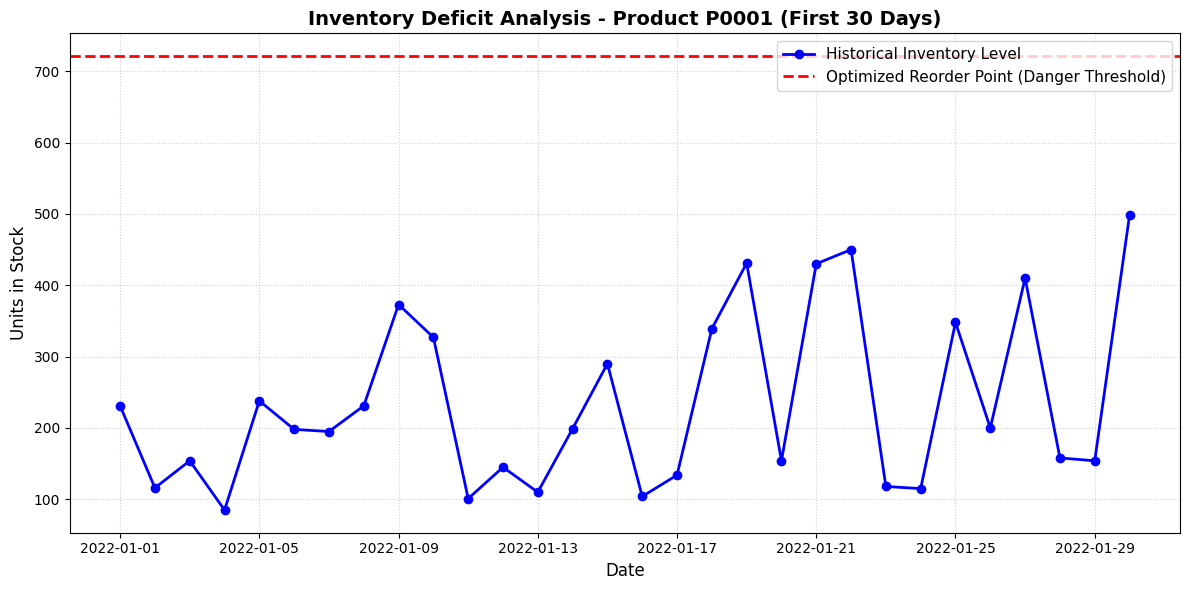

In [13]:
import matplotlib.pyplot as plt

# Isolate data for Product P0001 at Store S001 over the first 30 days
sample_df = df_eval[(df_eval['Product ID'] == 'P0001') & (df_eval['Store ID'] == 'S0001')].sort_values('Date').head(30)

# If S0001 doesn't have enough data, let's just grab the first store that shows up for P0001
if len(sample_df) == 0:
    first_store = df_eval[df_eval['Product ID'] == 'P0001']['Store ID'].iloc[0]
    sample_df = df_eval[(df_eval['Product ID'] == 'P0001') & (df_eval['Store ID'] == first_store)].sort_values('Date').head(30)

plt.figure(figsize=(12, 6))

# Plot historical inventory levels
plt.plot(sample_df['Date'], sample_df['Inventory'], label='Historical Inventory Level', color='blue', linewidth=2, marker='o')

# Plot your optimized Reorder Point as a baseline danger zone
plt.axhline(y=sample_df['Reorder_Point'].iloc[0], color='red', linestyle='--', linewidth=2, label='Optimized Reorder Point (Danger Threshold)')

plt.title('Inventory Deficit Analysis - Product P0001 (First 30 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Units in Stock', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [14]:
# 1. Engineering the ideal Target Stock Level (Up-to-To Level)
optimization_df['Target_Stock'] = (
    (optimization_df['Avg_Daily_Sales'] * LEAD_TIME) + 
    optimization_df['Safety_Stock']
)

# 2. Merge this ideal target baseline back into our evaluation set
df_eval = df_eval.merge(optimization_df[['Product ID', 'Target_Stock']], on='Product ID', how='left')

# 3. Calculate the "Deficit" (The missing units the store should have ordered)
df_eval['Inventory_Deficit'] = df_eval['Target_Stock'] - df_eval['Inventory']

# 4. Aggregate the total structural deficit across the entire operation
avg_deficit_units = df_eval['Inventory_Deficit'].mean()
estimated_holding_cost_per_unit_day = 0.15  # Assume $0.15 holding cost per unit/day
total_yearly_investment_needed = avg_deficit_units * 73100 * estimated_holding_cost_per_unit_day

print("--- Operational Optimization Analysis ---")
print(f"On average, stores faced a daily deficit of {avg_deficit_units:.1f} units per SKU.")
print(f"To eliminate stock-outs completely, the business must invest an estimated ${total_yearly_investment_needed:,.2f} in working capital.")

--- Operational Optimization Analysis ---
On average, stores faced a daily deficit of 446.2 units per SKU.
To eliminate stock-outs completely, the business must invest an estimated $4,892,490.95 in working capital.
